In [1]:
from __future__ import print_function
from tensorflow import keras
import numpy as np
from six.moves import range
from matplotlib import pyplot as plt
import numpy as np

In [2]:
DIGITS = 3
TRAINING_SIZE = 1000000
REVERSE = False

In [3]:
class CharacterTable(object):
    def __init__(self, chars):
        self.chars = sorted(set(chars))
        self.char_indices = dict((c, i) for i, c in enumerate(self.chars))
        self.indices_char = dict((i, c) for i, c in enumerate(self.chars))

    def encode(self, C, num_rows):
        x = np.zeros((num_rows, len(self.chars)))
        for i, c in enumerate(C):
            x[i, self.char_indices[c]] = 1
        return x

    def decode(self, x, calc_argmax=True):
        if calc_argmax:
            x = x.argmax(axis=-1)
        return ''.join(self.indices_char[x] for x in x)

class colors:
    ok = '\033[92m'
    fail = '\033[91m'
    close = '\033[0m'

MAXLEN = DIGITS + 1 + DIGITS

chars = '0123456789+-*/ '
ctable = CharacterTable(chars)

questions = []
expected = []
seen = set()

print('Generating data...')
ops = ['+', '-', '*', '/']

while len(questions) < TRAINING_SIZE:
    f = lambda: int(''.join(np.random.choice(list('0123456789'))
                    for i in range(np.random.randint(1, DIGITS + 1))))
    a, b = f(), f()
    op = np.random.choice(ops)

    # Avoid division by zero
    if op == '/' and b == 0:
        continue

    try:
        if op == '+':
            ans = a + b
        elif op == '-':
            ans = a - b
        elif op == '*':
            ans = a * b
        elif op == '/':
            ans = a // b
    except ZeroDivisionError:
        continue


    q = f"{a}{op}{b}"
    query = q + ' ' * (MAXLEN - len(q))
    ans_str = str(ans)

    ans_str += ' ' * (DIGITS * 2 - len(ans_str))

    if REVERSE:
        query = query[::-1]

    questions.append(query)
    expected.append(ans_str)

print('Total samples:', len(questions))

"""# Vectorization"""

x = np.zeros((len(questions), MAXLEN, len(chars)), dtype=bool)
y = np.zeros((len(questions), DIGITS * 2, len(chars)), dtype=bool)


for i, sentence in enumerate(questions):
    x[i] = ctable.encode(sentence, MAXLEN)
for i, sentence in enumerate(expected):
    y[i] = ctable.encode(sentence, DIGITS * 2)

# Shuffle
indices = np.arange(len(y))
np.random.shuffle(indices)
x = x[indices]
y = y[indices]

# Split train/validation
split_at = len(x) - len(x) // 10
(x_train, x_val) = x[:split_at], x[split_at:]
(y_train, y_val) = y[:split_at], y[split_at:]

print('Training Data:', x_train.shape)
print('Validation Data:', x_val.shape)


Generating data...
Total samples: 1000000
Training Data: (900000, 7, 15)
Validation Data: (100000, 7, 15)


In [4]:
for i in range(100):
    print('{} => {}'.format(questions[i], expected[i]))

7/726   => 0     
6+0     => 6     
3/626   => 0     
1/548   => 0     
84-5    => 79    
2/968   => 0     
99/45   => 2     
89+33   => 122   
11+611  => 622   
953-2   => 951   
270-66  => 204   
84*525  => 44100 
581*8   => 4648  
712+5   => 717   
444-784 => -340  
97*11   => 1067  
7+697   => 704   
452/76  => 5     
99+4    => 103   
65*175  => 11375 
20+93   => 113   
340-52  => 288   
9*2     => 18    
7+4     => 11    
590+80  => 670   
2/5     => 0     
10-5    => 5     
5+7     => 12    
3-6     => -3    
4/45    => 0     
54-650  => -596  
51-78   => -27   
429-987 => -558  
376*73  => 27448 
524-32  => 492   
81*685  => 55485 
35-510  => -475  
937+43  => 980   
60/5    => 12    
8/73    => 0     
31+64   => 95    
72/975  => 0     
864*17  => 14688 
599+558 => 1157  
206/9   => 22    
2*5     => 10    
85*52   => 4420  
5*1     => 5     
970/94  => 10    
755-128 => 627   
78+2    => 80    
98+31   => 129   
87/45   => 1     
9+0     => 9     
0*63    => 0     
2/2     =>

In [5]:
import numpy as np

def preds_to_texts(preds, ctable):
    idx = np.argmax(preds, axis=-1)
    texts = []
    for row in idx:
        texts.append(''.join(ctable.indices_char[i] for i in row).rstrip())
    return texts

def exact_match_rate(y_true_onehot, y_pred_probs, ctable):
    y_true_idx = np.argmax(y_true_onehot, axis=-1)
    true_texts = [''.join(ctable.indices_char[i] for i in row).rstrip() for row in y_true_idx]
    pred_texts = preds_to_texts(y_pred_probs, ctable)
    matches = [1 if t == p else 0 for t, p in zip(true_texts, pred_texts)]
    return np.mean(matches), true_texts, pred_texts


In [6]:
def train_model(RNN):
    HIDDEN_SIZE = 128
    BATCH_SIZE = 128
    LAYERS = 1

    model = keras.models.Sequential()
    model.add(RNN(HIDDEN_SIZE, input_shape=(MAXLEN, len(chars))))
    model.add(keras.layers.RepeatVector(DIGITS * 2))

    for _ in range(LAYERS):
        model.add(RNN(HIDDEN_SIZE * 2, return_sequences=True))

    model.add(keras.layers.Dense(len(chars), activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    model.summary()

    train_acc = []
    valid_acc = []

    for iteration in range(1, 100):
        print()
        print('-' * 50)
        print('Iteration', iteration)

        history = model.fit(
            x_train, y_train,
            batch_size=BATCH_SIZE,
            epochs=1,
            verbose=2,
            validation_data=(x_val, y_val)
        )

        train_acc.append(history.history['accuracy'][0])
        valid_acc.append(history.history['val_accuracy'][0])

        # Real Accuracy
        preds_val = model.predict(x_val, verbose=0)
        exact_acc, true_texts, pred_texts = exact_match_rate(y_val, preds_val, ctable)
        print(f'Exact-match accuracy: {exact_acc:.4f}')


        for i in range(10):
            ind = np.random.randint(0, len(x_val))
            rowx, rowy = x_val[np.array([ind])], y_val[np.array([ind])]
            preds = model.predict(rowx, verbose=0)
            preds = np.argmax(preds, axis=-1)
            q = ctable.decode(rowx[0])
            correct = ctable.decode(rowy[0])
            guess = ctable.decode(preds[0], calc_argmax=False)
            print('Q', q[::-1] if REVERSE else q, end=' ')
            print('T', correct, end=' ')
            if correct == guess:
                print(colors.ok + '☑' + colors.close, end=' ')
            else:
                print(colors.fail + '☒' + colors.close, end=' ')
            print(guess)

    plt.plot(train_acc, 'r')
    plt.plot(valid_acc, 'b')
    plt.show()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 6, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6, 15)          │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,847 (472.06 KB)

 Trainable params: 120,847 (472.06 KB)

 Non-trainable params: 0 (0.00 B)


--------------------------------------------------
Iteration 1
7032/7032 - 35s - 5ms/step - accuracy: 0.7835 - loss: 0.5963 - val_accuracy: 0.8507 - val_loss: 0.4021
Exact-match accuracy: 0.5340
Q 0+48    T 48     ☑ 48    
Q 3/95    T 0      ☑ 0     
Q 0+917   T 917    ☑ 917   
Q 693+873 T 1566   ☒ 1548  
Q 82/2    T 41     ☒ 21    
Q 50/63   T 0      ☑ 0     
Q 720-3   T 717    ☒ 727   
Q 1-2     T -1     ☑ -1    
Q 1/49    T 0      ☑ 0     
Q 88*76   T 6688   ☒ 6148  

--------------------------------------------------
Iteration 2
7032/7032 - 29s - 4ms/step - accuracy: 0.8685 - loss: 0.3505 - val_accuracy: 0.8775 - val_loss: 0.3249
Exact-match accuracy: 0.6108
Q 905-521 T 384    ☒ 342   
Q 78-4    T 74     ☑ 74    
Q 9*3     T 27     ☑ 27    
Q 7/9     T 0      ☑ 0     
Q 6+900   T 906    ☑ 906   
Q 642/2   T 321    ☒ 370   
Q 4-2     T 2      ☑ 2     
Q 2-109   T -107   ☑ -107  
Q 35/202  T 0      ☑ 0     
Q 0/9     T 0      ☑ 0     

-----------------------------------------------

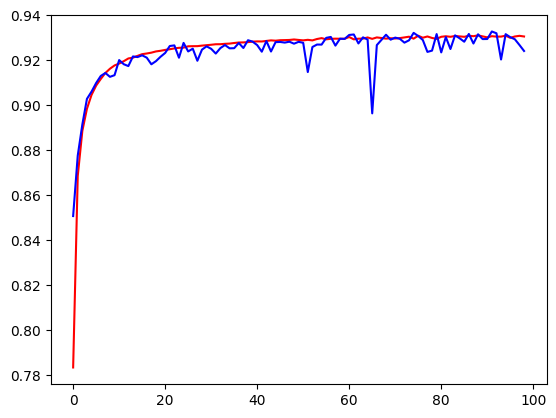

In [ ]:
train_model(keras.layers.SimpleRNN)

# LSTM

In [ ]:
train_model(keras.layers.LSTM)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 6, 256)         │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6, 15)          │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471,823 (1.80 MB)

 Trainable params: 471,823 (1.80 MB)

 Non-trainable params: 0 (0.00 B)


--------------------------------------------------
Iteration 1


# GRU